In [23]:
import pandas as pd
import matplotlib.pyplot as plt

In [78]:
data = pd.read_csv("../data/dpt2020.csv", sep=';')

data = data.rename(columns={
    'sexe': 'sex',
    'preusuel': 'first_name',
    'annais': 'birth_year',
    'dpt': 'department',
    'nombre': 'count',
})

data['sex'] = data['sex'].map({1: 'male', 2: 'female'})
data['birth_year'] = pd.to_numeric(data['birth_year'], errors='coerce')
data['is_rare_name'] = data['first_name'] == '_PRENOMS_RARES'
data['is_unknown_department'] = data['department'] == 'XX'

data.sample(10)

,sex,first_name,birth_year,department,count,is_rare_name,is_unknown_department
40288,male,AHMED,1957.0,38,3,False,False
2277471,female,DOMINIQUE,1963.0,974,39,False,False
2941660,female,LUDIVINE,1976.0,01,3,False,False
3438459,female,REGINA,1931.0,13,4,False,False
2302301,female,ELÉNNA,NaN,XX,21,False,True
137166,male,ANTOINE,1900.0,13,68,False,False
1418865,male,RENÉ,1928.0,09,49,False,False
434419,male,ELISE,1906.0,62,3,False,False
1275413,male,NOËL,1937.0,54,8,False,False
1831109,female,AMANDINE,1995.0,08,25,False,False


Text(0.5, 0, 'Year')

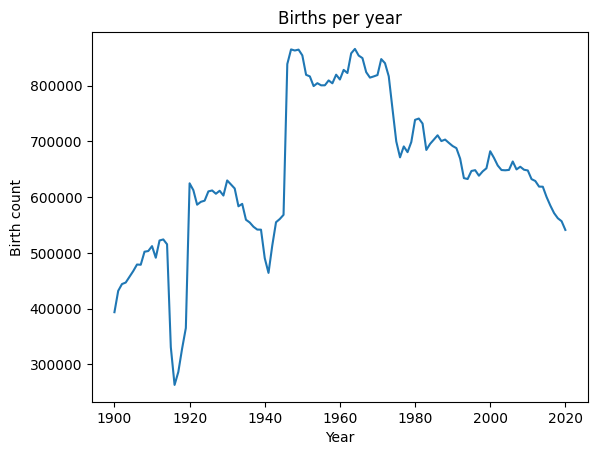

In [ ]:
birth_count_per_year = data.groupby('birth_year')['count'].sum()
ax = birth_count_per_year.plot()
ax.set_title('Births per year')
ax.set_xlabel('Year')
ax.set_ylabel('Birth count')

Text(0, 0.5, 'Name count')

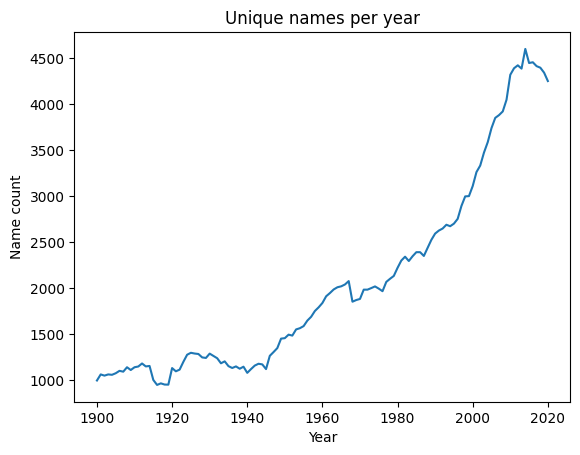

In [69]:
unique_name_count_per_year = data.groupby('birth_year')['first_name'].nunique()
ax = unique_name_count_per_year.plot()
ax.set_title('Unique names per year')
ax.set_xlabel('Year')
ax.set_ylabel('Name count')

In [79]:
top_names = data[~data.is_rare_name].groupby('first_name')['count'].sum().sort_values(ascending=False)
top_names.head(10)

first_name
MARIE       2259135
JEAN        1914606
PIERRE       892531
MICHEL       820534
ANDRÉ        712578
JEANNE       559437
PHILIPPE     538806
LOUIS        525406
RENÉ         516633
ALAIN        506944
Name: count, dtype: int64